In [1]:
!pip install dash
import pandas as pd

# Veriyi yükle
df = pd.read_csv('clean_data.csv')

#Hangi sütunlar var?
print("--- Veri Sütunları ---")
print(df.columns)

# 2. Boy ve Zıplama değerleri
print("\n--- Genel Fiziksel Ortalamalar ---")
try:
    print(df[['height', 'spike', 'block']].mean())
except:
    print("Sütun isimlerini kontrol etmemiz gerekiyor.")

#İlk 5 oyuncuyu görelim
df.head()

--- Veri Sütunları ---
Index(['index', 'name', 'date_of_birth', 'height', 'weight', 'spike', 'block',
       'position_number', 'country'],
      dtype='object')

--- Genel Fiziksel Ortalamalar ---
height    180.979167
spike     286.784722
block     275.506944
dtype: float64


,index,name,date_of_birth,height,weight,spike,block,position_number,country
0,0,Angelina Lazarenko,13/04/1998,193,80,320,305,3,23
1,1,Svetlana Serbina,15/05/1996,182,71,295,284,1,23
2,2,Ekaterina Shkurikhina,17/06/1996,190,72,306,296,2,23
3,3,Kristina Kurnosova,17/06/1997,176,62,288,278,6,23
4,4,Ekaterina Novikova,07/12/1996,181,70,290,275,1,23


In [2]:
# Mevki numaralarına göre fiziksel ortalamalar
mevki_analizi = df.groupby('position_number')[['height', 'spike', 'block']].mean()
print("--- Mevki Bazlı Fiziksel Standartlar ---")
print(mevki_analizi)

#"Zıplama Verimliliği". Boyuna oranla kim daha etkili zıplıyor? 
df['jump_power'] = (df['spike'] - df['height']) 

#Kendi boyuna göre en yüksek farkı yaratan ilk 5 oyuncu
print("\n--- En Patlayıcı (Boy-Smaç Farkı En Yüksek) 5 Oyuncu ---")
top_jumpers = df[['name', 'position_number', 'height', 'spike', 'jump_power']].sort_values(by='jump_power', ascending=False).head()
print(top_jumpers)

--- Mevki Bazlı Fiziksel Standartlar ---
                     height       spike       block
position_number                                    
1                176.880000  285.840000  274.440000
2                179.916667  286.041667  274.062500
3                186.888889  297.000000  285.333333
4                184.666667  283.285714  271.190476
6                171.214286  270.000000  263.571429

--- En Patlayıcı (Boy-Smaç Farkı En Yüksek) 5 Oyuncu ---
                         name  position_number  height  spike  jump_power
416        Paola Ogechi Egonu                4     190    336         146
128        Paola Ogechi Egonu                4     190    336         146
272        Paola Ogechi Egonu                4     190    336         146
368  Anaila Martinez Chaviano                1     184    320         136
80   Anaila Martinez Chaviano                1     184    320         136


--- Temizlenmiş En Patlayıcı 5 Oyuncu ---
                         name  position_number  height  spike  jump_power
128        Paola Ogechi Egonu                4     190    336         146
80   Anaila Martinez Chaviano                1     184    320         136
78       Ailama Cese Montalvo                2     188    322         134
31            Mizuki Yanagita                2     168    300         132
124            Sara Bonifacio                3     188    320         132


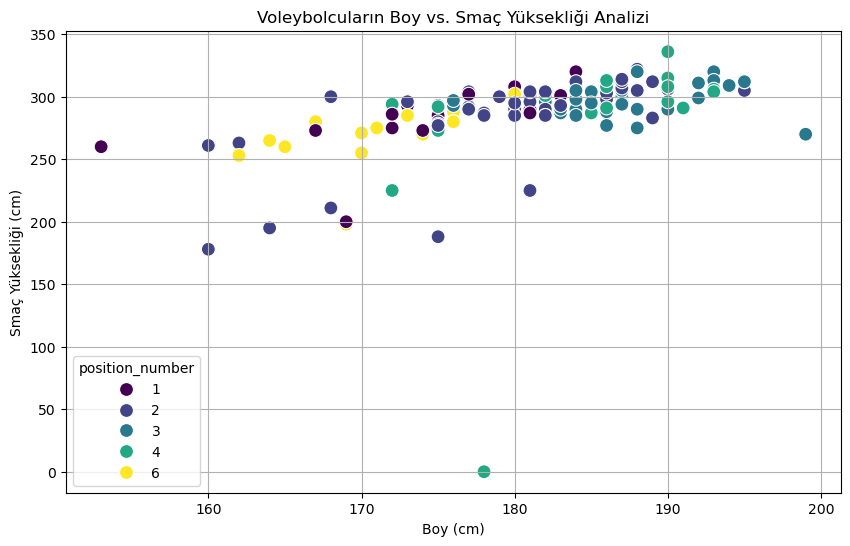

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Duplicate kayıtları temizle
df_clean = df.drop_duplicates(subset=['name'])

# 2. Temiz veriyle "En Patlayıcı 5 Oyuncu"
print("--- Temizlenmiş En Patlayıcı 5 Oyuncu ---")
top_jumpers_clean = df_clean[['name', 'position_number', 'height', 'spike', 'jump_power']].sort_values(by='jump_power', ascending=False).head()
print(top_jumpers_clean)

#Mevkilere Göre Boy ve Smaç Yüksekliği İlişkisi
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='height', y='spike', hue='position_number', palette='viridis', s=100)
plt.title('Voleybolcuların Boy vs. Smaç Yüksekliği Analizi')
plt.xlabel('Boy (cm)')
plt.ylabel('Smaç Yüksekliği (cm)')
plt.grid(True)
plt.show()

In [4]:
#"Hızlı Arama" Fonksiyonu
def oyuncu_bul(min_spike, max_height):
    # Belirli bir smaç yüksekliğinin üzerinde ama boyu şu seviyenin altında olan "verimli" oyuncular
    filtre = df_clean[(df_clean['spike'] >= min_spike) & (df_clean['height'] <= max_height)]
    return filtre[['name', 'country', 'height', 'spike', 'jump_power']].sort_values(by='spike', ascending=False)

# Örnek: "Bana boyu 185'ten kısa ama 310+ smaç vuran oyuncuları getir"
ozel_liste = oyuncu_bul(min_spike=310, max_height=185)
print("--- Antrenörün Özel Scouting Listesi ---")
print(ozel_liste)

--- Antrenörün Özel Scouting Listesi ---
                         name  country  height  spike  jump_power
80   Anaila Martinez Chaviano       31     184    320         136
116              Angela Leyva       30     184    312         128


In [5]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd

#Veriyi hazırlama ve temizleme
df = pd.read_csv('clean_data.csv')
df_clean = df.drop_duplicates(subset=['name']).copy()
df_clean['jump_power'] = df_clean['spike'] - df_clean['height']

# Dash Uygulamasını Başlatma
app = Dash(__name__)

app.layout = html.Div([
    html.H1("Voleybol Scouting Karar Destek Paneli", 
            style={'textAlign': 'center', 'color': '#2c3e50', 'fontFamily': 'Arial'}),
    
    html.Div([
        html.Div([
            html.Label("Minimum Smaç Yüksekliği (cm):", style={'fontWeight': 'bold'}),
            dcc.Slider(id='spike-slider', min=250, max=350, step=5, value=300,
                       marks={i: str(i) for i in range(250, 351, 20)}),
        ], style={'width': '48%', 'display': 'inline-block'}),

        html.Div([
            html.Label("Maksimum Boy (cm):", style={'fontWeight': 'bold'}),
            dcc.Slider(id='height-slider', min=160, max=210, step=1, value=185,
                       marks={i: str(i) for i in range(160, 211, 10)}),
        ], style={'width': '48%', 'display': 'inline-block', 'float': 'right'}),
    ], style={'padding': '20px', 'backgroundColor': '#f9f9f9', 'borderRadius': '10px'}),

    dcc.Graph(id='scout-graph')
], style={'padding': '20px'})

@app.callback(
    Output('scout-graph', 'figure'),
    [Input('spike-slider', 'value'),
     Input('height-slider', 'value')]
)
def update_graph(min_spike, max_height):
    # Filtreleme işlemi
    filtered_df = df_clean[(df_clean['spike'] >= min_spike) & (df_clean['height'] <= max_height)]
    
    # Grafik oluşturma
    fig = px.scatter(filtered_df, 
                     x="height", 
                     y="spike", 
                     hover_name="name", 
                     color="jump_power",
                     size="jump_power", # Patlayıcılık gücüne göre noktaların büyüklüğü değişsin
                     color_continuous_scale="Viridis",
                     labels={"height": "Boy (cm)", "spike": "Smaç Yüksekliği (cm)", "jump_power": "Zıplama Gücü"},
                     title=f"Kriterlere Uygun {len(filtered_df)} Oyuncu Bulundu")
    
    fig.update_layout(transition_duration=500)
    return fig

if __name__ == '__main__':
    app.run(mode='inline', port=8060)